# Reinsurance Treaty Simulator
## Simulación y comparación de tratados de reaseguro con distribuciones de cola pesada

**Autor:** Mario Sánchez Flores  
**Carrera:** Actuaría  
**Fecha:** Mayo 2026

---

## Resumen

Este proyecto modela el impacto de tres estructuras de reaseguro sobre un portafolio 
de siniestros simulados con distribuciones de cola pesada. Usando el modelo colectivo 
de riesgo con frecuencia Poisson y severidad Pareto, comparamos cómo cada tratado 
transforma la distribución de pérdidas retenidas por la aseguradora, medido a través 
de métricas actuariales estándar: VaR 99%, CVaR 99%, pérdida media y prima técnica.

**Tratados analizados:**
- Cuota Parte (*Quota Share*) con $\alpha = 0.40$
- Exceso de Pérdida (*Excess of Loss*) con $M = 100,000$ y $L = 400,000$
- Stop-Loss Agregado con $D = 150,000$ y $C = 5,000,000$

## 1. Motivación

El capital de una aseguradora evoluciona como:

$$S_n = u + \sum_{j=1}^{n}(p - Y_j)$$

donde $u$ es el capital inicial y $p$ es la prima cobrada por periodo.
Si los siniestros $Y_j$ son muy grandes, $S_n$ puede volverse negativo
y la aseguradora quiebra. El reaseguro transfiere parte de ese riesgo
a un reasegurador a cambio de ceder parte de la prima.

**Pregunta central:** ¿Cómo impacta cada estructura de reaseguro
la distribución de pérdidas retenidas por la aseguradora?

## 2. Modelo Matemático

Usamos el **Modelo Colectivo de Riesgo**:

$$S = \sum_{j=1}^{N} Y_j$$

| Componente | Distribución | Parámetros |
|-----------|-------------|------------|
| Frecuencia $N$ | Poisson | $\lambda = 50$ |
| Severidad $Y_j$ (escenario 1) | Pareto | $\alpha = 1.5$, $x_m = 1,000$ |
| Severidad $Y_j$ (escenario 2) | Lognormal | $\mu = 8$, $\sigma = 1.5$ |

Simulamos $100,000$ escenarios anuales para obtener
la distribución empírica de $S$.

### ¿Por qué distribuciones de cola pesada?

Las pérdidas en seguros tienen probabilidades no despreciables de eventos
extremos. La Pareto con $\alpha = 1.5$ tiene varianza infinita, modelando
siniestros catastróficos. La Lognormal tiene cola más ligera pero siniestros
típicos más grandes.

In [35]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.treaties import apply_quota_share, apply_excess_of_loss, apply_stop_loss

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Cargar datos simulados
df          = pd.read_csv("../data/simulated_losses.csv")
S_pareto    = df["S_pareto"].values
S_lognormal = df["S_lognormal"].values

print(f"Escenarios cargados : {len(S_pareto):,}")
print(f"Media Pareto        : {S_pareto.mean():,.2f}")
print(f"Media Lognormal     : {S_lognormal.mean():,.2f}")

Escenarios cargados : 100,000
Media Pareto        : 149,069.14
Media Lognormal     : 458,928.03


## 3. Simulación de Siniestros

Visualizamos las distribuciones brutas de ambos escenarios
antes de aplicar cualquier tratado de reaseguro.

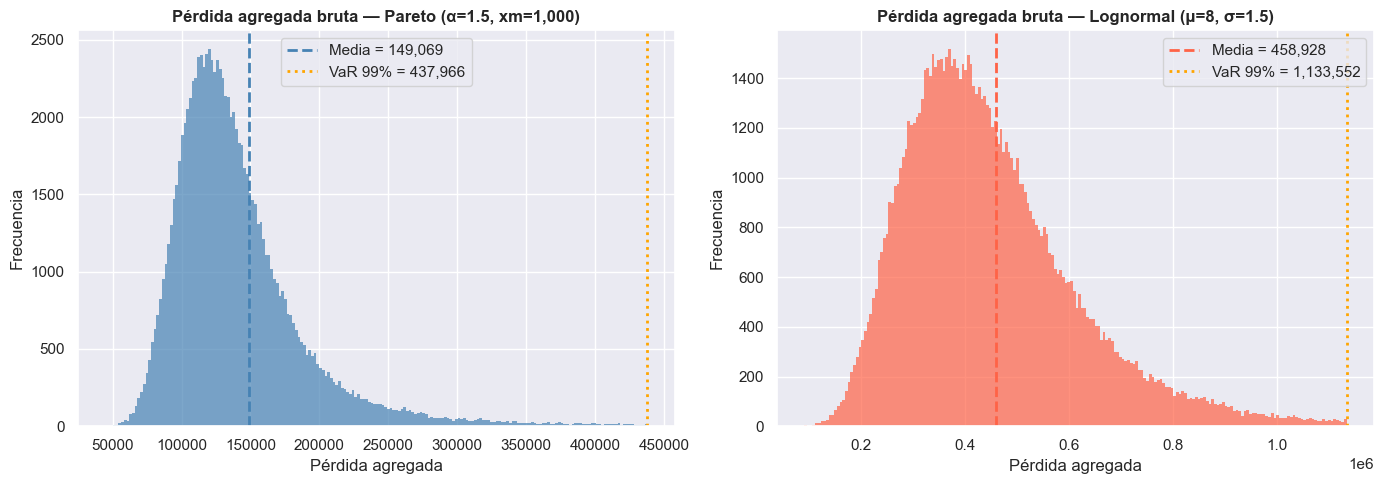

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, S, nombre, color in zip(
    axes,
    [S_pareto, S_lognormal],
    ["Pareto (α=1.5, xm=1,000)", "Lognormal (μ=8, σ=1.5)"],
    ["steelblue", "tomato"]
):
    p99  = np.percentile(S, 99)
    zoom = S[S <= p99]
    ax.hist(zoom, bins=200, color=color, alpha=0.7, edgecolor="none")
    ax.axvline(S.mean(), color=color,    linewidth=2, linestyle="--", label=f"Media = {S.mean():,.0f}")
    ax.axvline(p99,      color="orange", linewidth=2, linestyle=":",  label=f"VaR 99% = {p99:,.0f}")
    ax.set_title(f"Pérdida agregada bruta — {nombre}", fontweight="bold")
    ax.set_xlabel("Pérdida agregada")
    ax.set_ylabel("Frecuencia")
    ax.legend()

plt.tight_layout()
plt.savefig("../figures/10_brutas_comparadas.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Aplicación de los Tres Tipos de Reaseguro

Aplicamos los tres tratados sobre ambas distribuciones de severidad.
Los parámetros son idénticos para hacer la comparación justa.

| Tratado | Parámetros |
|---------|-----------|
| Quota Share | $\alpha = 0.40$ |
| Excess of Loss | $M = 100,000$, $L = 400,000$ |
| Stop-Loss | $D = 150,000$, $C = 5,000,000$ |

In [ ]:
#  Quota Share
ret_qs_pareto    = apply_quota_share(S_pareto,    alpha=0.40)["retained"]
ret_qs_lognormal = apply_quota_share(S_lognormal, alpha=0.40)["retained"]

#  Stop-Loss
ret_sl_pareto    = apply_stop_loss(S_pareto,    D=150_000, C=5_000_000)["retained"]
ret_sl_lognormal = apply_stop_loss(S_lognormal, D=150_000, C=5_000_000)["retained"]

#  Excess of Loss — Pareto
rng = np.random.default_rng(42)
N   = rng.poisson(lam=50.0, size=100_000)
ret_xl_pareto = np.zeros(100_000)
for i, n in enumerate(N):
    if n == 0:
        continue
    U = rng.uniform(size=n)
    Y = 1_000.0 / (U ** (1.0 / 1.5))
    ret_xl_pareto[i] = apply_excess_of_loss(Y, M=100_000, L=400_000)["retained"].sum()

#  Excess of Loss — Lognormal 
rng2 = np.random.default_rng(42)
N2   = rng2.poisson(lam=50.0, size=100_000)
ret_xl_lognormal = np.zeros(100_000)
for i, n in enumerate(N2):
    if n == 0:
        continue
    Y = rng2.lognormal(mean=8.0, sigma=1.5, size=n)
    ret_xl_lognormal[i] = apply_excess_of_loss(Y, M=100_000, L=400_000)["retained"].sum()

print("Tratados aplicados correctamente")
print(f"XL Pareto    media: {ret_xl_pareto.mean():,.2f}")
print(f"XL Lognormal media: {ret_xl_lognormal.mean():,.2f}")

Tratados aplicados correctamente
XL Pareto    media: 139,919.83
XL Lognormal media: 415,221.92


## 5. Comparación de Métricas Actuariales

Calculamos VaR 99%, CVaR 99%, pérdida media y prima técnica
para cada combinación de tratado y distribución de severidad.

In [38]:
def resumen_metricas(S, nombre):
    var99  = np.percentile(S, 99)
    cvar99 = S[S >= var99].mean()
    media  = S.mean()
    std    = S.std()
    prima  = media + 1.5 * std
    return {
        "Tratado"        : nombre,
        "Media"          : media,
        "Desv. Estándar" : std,
        "VaR 99%"        : var99,
        "CVaR 99%"       : cvar99,
        "Prima Técnica"  : prima,
    }

# Tabla Pareto
print("=" * 70)
print("PARETO (α=1.5, xm=1,000)")
print("=" * 70)
df_pareto = pd.DataFrame([
    resumen_metricas(S_pareto,       "Bruto"),
    resumen_metricas(ret_qs_pareto,  "Quota Share"),
    resumen_metricas(ret_xl_pareto,  "Excess of Loss"),
    resumen_metricas(ret_sl_pareto,  "Stop-Loss"),
]).set_index("Tratado")
print(df_pareto.map(lambda x: f"{x:,.2f}"))

print()

# Tabla Lognormal
print("=" * 70)
print("LOGNORMAL (μ=8, σ=1.5)")
print("=" * 70)
df_lognormal = pd.DataFrame([
    resumen_metricas(S_lognormal,       "Bruto"),
    resumen_metricas(ret_qs_lognormal,  "Quota Share"),
    resumen_metricas(ret_xl_lognormal,  "Excess of Loss"),
    resumen_metricas(ret_sl_lognormal,  "Stop-Loss"),
]).set_index("Tratado")
print(df_lognormal.map(lambda x: f"{x:,.2f}"))
# Ver métricas Stop-Loss Lognormal completas
sl_log = resumen_metricas(ret_sl_lognormal, "Stop-Loss Lognormal")
for k, v in sl_log.items():
    if k != "Tratado":
        print(f"{k:<20} : {v:,.2f}")

PARETO (α=1.5, xm=1,000)
                     Media Desv. Estándar     VaR 99%    CVaR 99%  \
Tratado                                                             
Bruto           149,069.14     204,664.09  437,966.07  943,990.34   
Quota Share      89,441.49     122,798.45  262,779.64  566,394.20   
Excess of Loss  139,919.83      43,009.30  276,153.70  308,078.07   
Stop-Loss       128,144.23     144,454.26  150,000.00  152,830.90   

               Prima Técnica  
Tratado                       
Bruto             456,065.27  
Quota Share       273,639.16  
Excess of Loss    204,433.77  
Stop-Loss         344,825.62  

LOGNORMAL (μ=8, σ=1.5)
                     Media Desv. Estándar       VaR 99%      CVaR 99%  \
Tratado                                                                 
Bruto           458,928.03     199,988.71  1,133,552.16  1,480,001.25   
Quota Share     275,356.82     119,993.23    680,131.30    888,000.75   
Excess of Loss  415,221.92     122,597.15    748,462.10   

## 6. Comparación Visual — Pareto vs Lognormal

Comparamos el impacto de cada tratado bajo ambas distribuciones
de severidad usando métricas actuariales normalizadas.

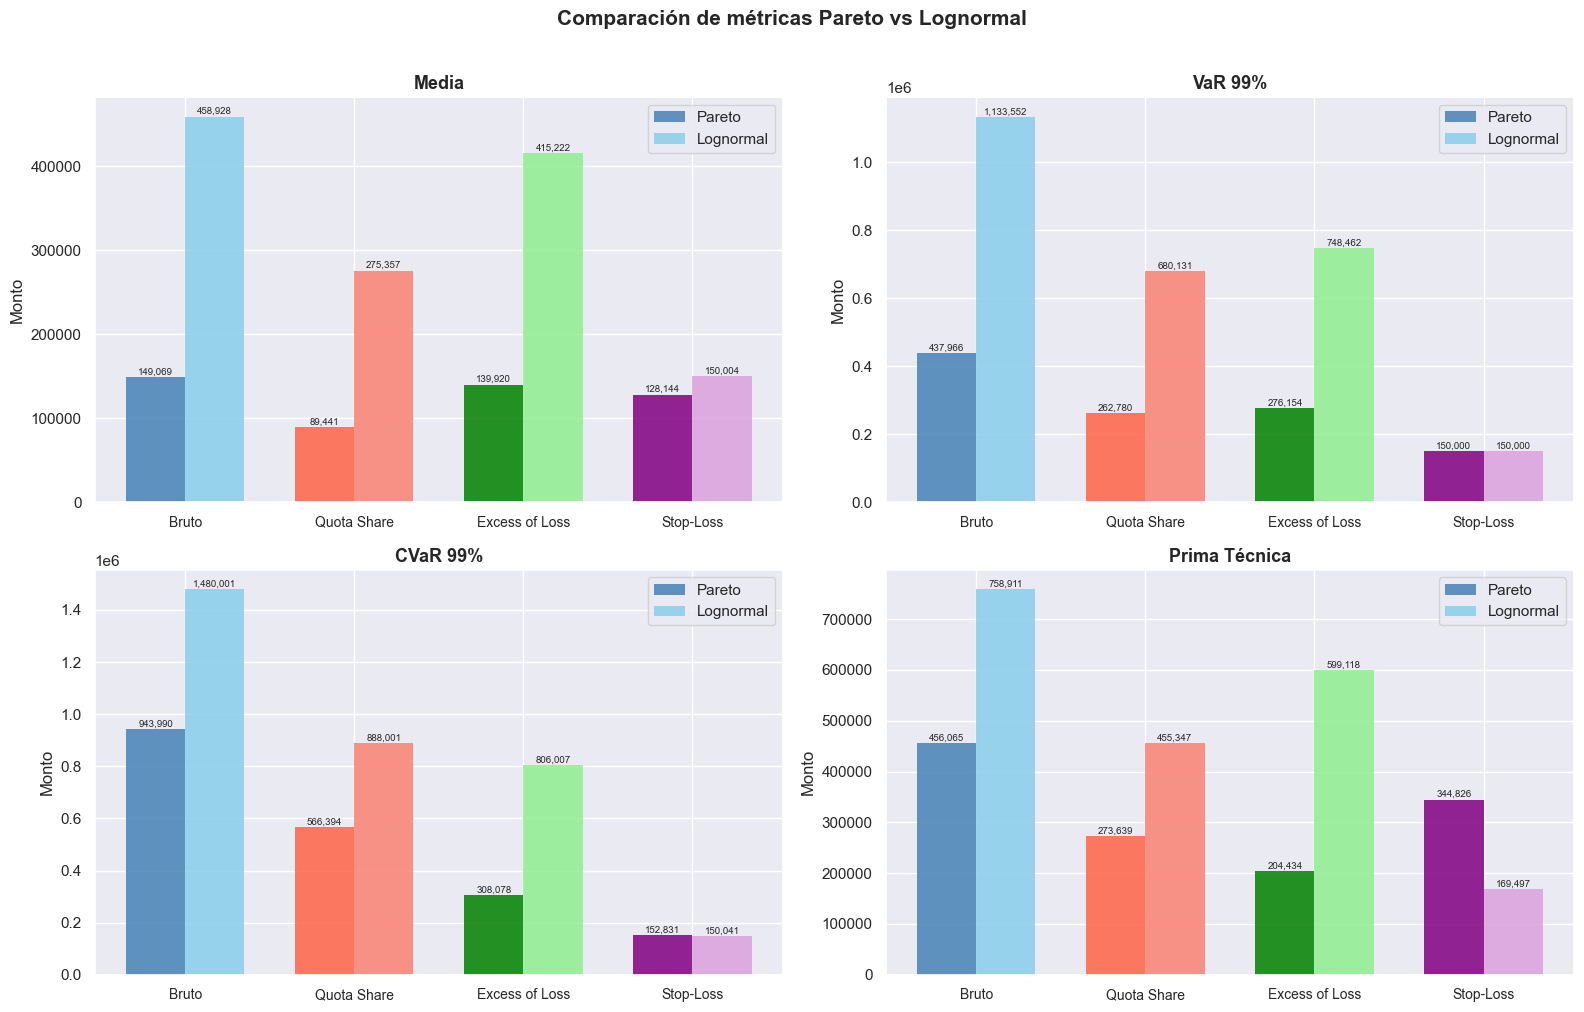

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metricas_cols = ["Media", "VaR 99%", "CVaR 99%", "Prima Técnica"]
tratados      = ["Bruto", "Quota Share", "Excess of Loss", "Stop-Loss"]
colores_par   = ["steelblue", "tomato", "green", "purple"]
colores_log   = ["skyblue",   "salmon", "lightgreen", "plum"]

for ax, col in zip(axes.flatten(), metricas_cols):
    x       = np.arange(len(tratados))
    ancho   = 0.35

    vals_par = df_pareto[col].values
    vals_log = df_lognormal[col].values

    bars1 = ax.bar(x - ancho/2, vals_par, ancho, label="Pareto",
                   color=colores_par, alpha=0.85, edgecolor="none")
    bars2 = ax.bar(x + ancho/2, vals_log, ancho, label="Lognormal",
                   color=colores_log, alpha=0.85, edgecolor="none")

    for bar, val in zip(bars1, vals_par):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f"{val:,.0f}", ha="center", va="bottom", fontsize=7)
    for bar, val in zip(bars2, vals_log):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f"{val:,.0f}", ha="center", va="bottom", fontsize=7)

    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(tratados, fontsize=10)
    ax.set_ylabel("Monto")
    ax.legend()

plt.suptitle("Comparación de métricas Pareto vs Lognormal",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../figures/11_pareto_vs_lognormal_metricas.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Conclusiones

### 7.1 Hallazgos principales

**Sobre la Cuota Parte:**
- Reduce todas las métricas proporcionalmente por el factor $(1-\alpha) = 0.60$
- No cambia la forma de la distribución, solo la escala
- Es la única transformación lineal: $S^{\text{retenido}} = 0.60 \cdot S$
- Fácil de administrar pero no protege contra eventos catastróficos

**Sobre el Excess of Loss:**
- Reduce drasticamente la variabilidad con Pareto ($\sigma: 204K \to 43K$)
- Acota la pérdida máxima por siniestro en $M$
- Ineficiente con Lognormal porque $M = 100K > \mathbb{E}[Y] = 9,198$
- Requiere ajustar $M$ según la severidad típica del portafolio

**Sobre el Stop-Loss:**
- Mejor VaR 99% en ambas distribuciones: exactamente $D$
- Mejor CVaR 99% en ambas distribuciones
- Más robusto ante distintas distribuciones de severidad
- Con Lognormal convierte el portafolio en casi perfectamente predecible

### 7.2 Insight actuarial central

$$\text{La efectividad del reaseguro depende de la distribución de pérdidas}$$

Un XL con $M = 100,000$ es óptimo para Pareto pero ineficiente para Lognormal.
Los parámetros deben calibrarse según las características del portafolio real.

### 7.3 Tabla resumen final

| Objetivo | Pareto | Lognormal |
|----------|--------|-----------|
| Menor prima técnica | **XL** | **Stop-Loss** |
| Menor VaR 99% | **Stop-Loss** | **Stop-Loss** |
| Menor CVaR 99% | **Stop-Loss** | **Stop-Loss** |
| Menor variabilidad | **XL** | **Stop-Loss** |
| Mayor simplicidad | **QS** | **QS** |

### 7.4 Limitaciones y trabajo futuro

- Solo se modeló una capa XL; en la práctica se usan múltiples capas
- Los parámetros de los tratados no fueron optimizados
- No se modeló el costo explícito del reaseguro (prima cedida)
- Extensión natural: ajustar $M$ óptimo para cada distribución